In [1]:
import numpy as np
from scipy.linalg import solve
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.utils.multiclass import unique_labels


class ELMClassifier(BaseEstimator, ClassifierMixin):
  """
  Fixed ELM Classifier with proper multi-class handling
  """
  
  _ACTIVATIONS = {
    'sigmoid': lambda x: 1 / (1 + np.exp(-x)),
    'relu': lambda x: np.maximum(0, x),
    'tanh': lambda x: np.tanh(x),
    'rbf': lambda x: np.exp(-(x**2))
  }

  def __init__(self, num_hidden=100, activation='sigmoid', reg_param=1e-3,
         weight_scale=1.0, bias_scale=0.1, random_state=None):
    self.num_hidden = num_hidden
    self.activation = activation
    self.reg_param = reg_param
    self.weight_scale = weight_scale
    self.bias_scale = bias_scale  # Reduced default bias scale
    self.random_state = random_state

  def fit(self, X, y):
    X, y = check_X_y(X, y)
    self._setup_activation()
    self._setup_classes(y)
    
    n_features = X.shape[1]
    self._init_weights(n_features)
    
    H = self._compute_hidden_layer(X)
    self._solve_output_weights(H, y)
    
    return self

  def predict(self, X):
    check_is_fitted(self)
    X = check_array(X)
    
    scores = self.decision_function(X)
    return self.classes_[np.argmax(scores, axis=1)]

  def decision_function(self, X):
    check_is_fitted(self)
    X = check_array(X)
    H = self._compute_hidden_layer(X)
    return H @ self.output_weights_

  def _setup_activation(self):
    if self.activation not in self._ACTIVATIONS:
      raise ValueError(f"Invalid activation '{self.activation}'. Valid options: {list(self._ACTIVATIONS.keys())}")
    self._activation_fn = self._ACTIVATIONS[self.activation]

  def _setup_classes(self, y):
    self.classes_ = unique_labels(y)
    self.n_classes_ = len(self.classes_)
    # Use OneHotEncoder for proper multi-class handling
    self._onehot_encoder = OneHotEncoder(sparse_output=False, categories=[self.classes_])
    self._onehot_encoder.fit(y.reshape(-1, 1))

  def _init_weights(self, n_features):
    rng = np.random.RandomState(self.random_state)
    # Xavier/Glorot initialization for better convergence
    std_dev = self.weight_scale * np.sqrt(2.0 / (n_features + self.num_hidden))
    self.input_weights_ = std_dev * rng.randn(n_features, self.num_hidden)
    self.biases_ = self.bias_scale * rng.randn(self.num_hidden)

  def _compute_hidden_layer(self, X):
    pre_activation = X @ self.input_weights_ + self.biases_
    return self._activation_fn(pre_activation)

  def _solve_output_weights(self, H, y):
    # Proper one-hot encoding with n_classes columns
    Y = self._onehot_encoder.transform(y.reshape(-1, 1))
    
    # Regularized least squares solution
    if H.shape[0] >= H.shape[1]:
      A = H.T @ H + self.reg_param * np.eye(self.num_hidden)
      B = H.T @ Y
    else:
      A = H @ H.T + self.reg_param * np.eye(H.shape[0])
      B = Y
      
    try:
      solution = solve(A, B, assume_a='pos')
      self.output_weights_ = H.T @ solution if H.shape[0] < H.shape[1] else solution
    except np.linalg.LinAlgError:
      self.output_weights_ = np.linalg.lstsq(A, B, rcond=None)[0]

Accuracy: 0.9400


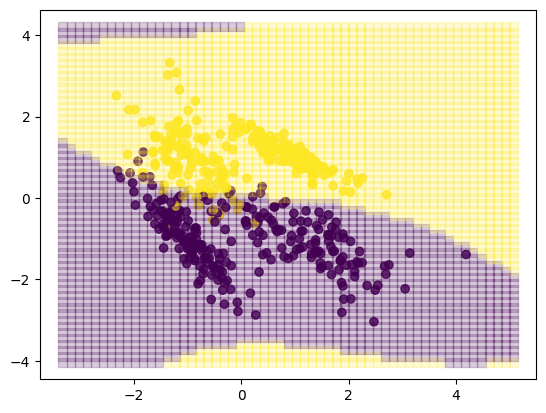

In [20]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate sample data
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Initialize and train ELM
elm = ELMClassifier()

elm.fit(X_train, y_train)

# Evaluate
y_pred = elm.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

def make_grid(X, step=1):
  """
  Create a grid of points for contour plotting
  
  Parameters
  ----------
  X : array-like of shape (n_samples, n_features)
    Input data
  step : float, default=1
    Step size for grid points
    
  Returns
  -------
  xx : ndarray of shape (n_points, 2)
    Grid points
  """

  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                       np.arange(y_min, y_max, step))
  
  return np.c_[xx.ravel(), yy.ravel()]

G = make_grid(X, step=0.15)

# Predict on grid points
Z = elm.predict(G)

import matplotlib.pyplot as plt

# Plot decision boundary
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)
plt.scatter(G[:, 0], G[:, 1], c=Z, alpha=0.2, marker='s')
plt.show()

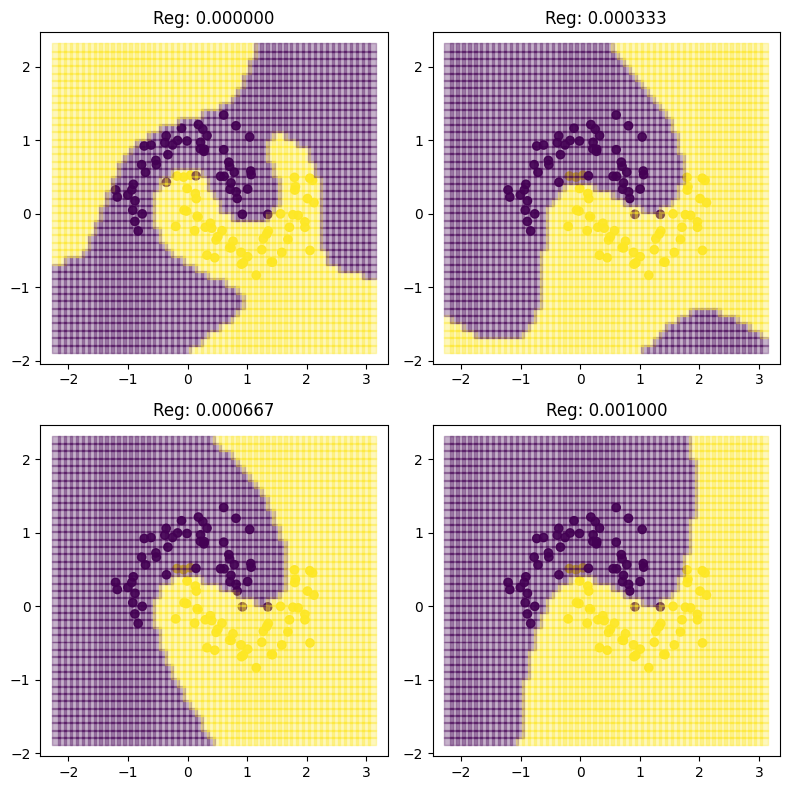

In [ ]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, noise=0.2, random_state=0)
G = make_grid(X, step=0.1)

regs = np.linspace(0, .001, 4)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.ravel()

for i, reg in enumerate(regs):
  elm = ELMClassifier(reg_param=reg, activation='rbf')
  elm.fit(X, y)
  Z = elm.predict(G)
  
  axes[i].scatter(X[:, 0], X[:, 1], c=y, alpha=0.9)
  axes[i].scatter(G[:, 0], G[:, 1], c=Z, alpha=0.3, marker='s')
  axes[i].set_title(f"Reg: {reg:.6f}")

plt.tight_layout()
plt.show()

We observe that as the regularization parameter increases, the decision boundary becomes smoother, trading off the fit to the training data for generalization. Higher regularization parameters mean that the training willingly accepts some error over the training set in order to be less impacted by the inherent uncertainty of the data and obtain smaller weights in the linear layer.